# 04 — Optimization and gradient descent

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

Training a model means solving $\min_{x \in \mathbb{R}^d} f(x)$. Closed-form solutions are the exception, so we *descend*: stand at $x_k$, look at the slope, step downhill, repeat. Everything interesting is in the details.

1. **Gradient descent** — which direction, and how far?
2. **Why it converges** — $L$-smoothness, the descent lemma, and the proofs
3. **Momentum** — inertia, acceleration, and the optimal rate
4. **Non-convex problems** — why stochastic gradients help

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA]),
    "axes.grid": False, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
})

## 1. Gradient descent

Replace $f$ near $x_k$ by its first-order Taylor expansion and add a quadratic term that penalizes long steps — we only trust the linear model locally:

$$x_{k+1} = \arg\min_{y \in \mathbb{R}^d} \Big\{ f(x_k) + \langle \nabla f(x_k),\, y - x_k \rangle + \tfrac{1}{2\eta}\|y - x_k\|^2 \Big\} = x_k - \eta \nabla f(x_k).$$

The gradient picks the direction, the **step size** $\eta > 0$ picks how far. Section 2 shows that the right scale for $\eta$ is set by the curvature of $f$.

Our test problem is the quadratic

$$f(x) = \tfrac12 x^\top A x, \qquad A = \operatorname{diag}(\mu, L), \quad \mu = 1,\ L = 20,$$

whose minimizer is $x^\star = 0$. Here gradient descent is a *linear* recursion, $x_{k+1} = (I - \eta A) x_k$, so

$$x_k = (I - \eta A)^k x_0, \qquad \text{$i$-th coordinate contracts by } |1 - \eta \lambda_i|.$$

It converges **iff** $\max_i |1 - \eta\lambda_i| < 1$, that is **iff $0 < \eta < 2/L$**: the largest eigenvalue alone dictates the largest admissible step.

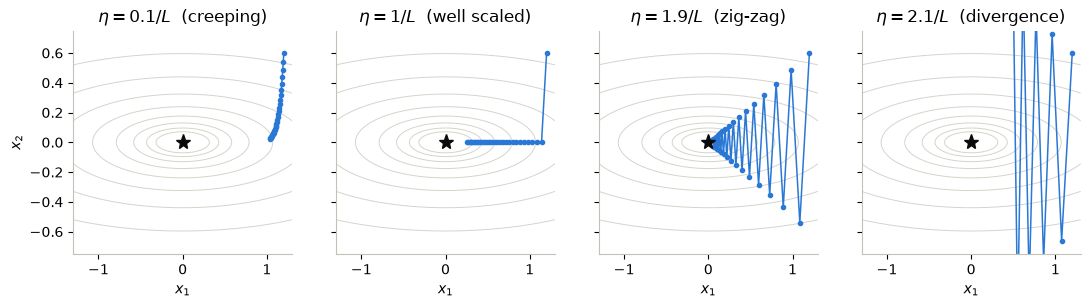

In [2]:
mu, L = 1.0, 20.0
A = np.diag([mu, L])
f, grad = lambda x: 0.5 * (x[..., 0]**2 * mu + x[..., 1]**2 * L), lambda x: A @ x

def gd(x0, eta, n=30):
    x, xs = np.array(x0, float), []
    for _ in range(n + 1):
        xs.append(x.copy())
        x = x - eta * grad(x)
    return np.array(xs)

g1, g2 = np.meshgrid(np.linspace(-1.3, 1.3, 300), np.linspace(-0.75, 0.75, 300))
Z = f(np.stack([g1, g2], -1))

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9), sharex=True, sharey=True)
for ax, (c, note) in zip(axes, [(0.1, "creeping"), (1, "well scaled"), (1.9, "zig-zag"), (2.1, "divergence")]):
    p = gd([1.2, 0.6], c / L, n=8 if c > 2 else 30)
    ax.contour(g1, g2, Z, levels=np.geomspace(0.05, 12, 10), colors="#d5d4cb", linewidths=0.7)
    ax.plot(*p.T, "-o", color=BLUE, ms=3, lw=1.1)
    ax.plot(0, 0, "*", color="#0b0b0b", ms=11)
    ax.set(title=rf"$\eta = {c}/L$  ({note})", xlabel="$x_1$", xlim=(-1.3, 1.3), ylim=(-0.75, 0.75))
axes[0].set_ylabel("$x_2$")
plt.show()

Two failure modes bracket the useful window:

- $\eta \ll 1/L$: every step is safe but tiny, and after 30 iterations the flat direction $x_1$ has barely moved.
- $\eta \to 2/L$: the sharp direction $x_2$ overshoots and flips sign at every step — the zig-zag across the valley — while $x_1$ still creeps.
- $\eta > 2/L$: $|1 - \eta L| > 1$ and the iterates blow up geometrically (only 8 steps are drawn).

The best step size balances the two extreme eigenvalues, $|1 - \eta\mu| = |1 - \eta L|$:

$$\eta^\star = \frac{2}{\mu + L}, \qquad\text{contraction}\qquad \frac{\kappa - 1}{\kappa + 1} = 1 - \frac{2}{\kappa + 1}, \qquad \kappa := \frac{L}{\mu},$$

where $\kappa$ is the **condition number**. Even at its best, gradient descent needs $O(\kappa \log \tfrac1\varepsilon)$ iterations: conditioning, not dimension, is what hurts.

## 2. Convergence under $L$-smoothness

For general $f$ we need one assumption, and it is exactly the assumption that made $2/L$ appear above.

**Assumption ($L$-smoothness).** $f$ is differentiable and $\nabla f$ is $L$-Lipschitz:

$$\|\nabla f(x) - \nabla f(y)\| \le L \|x - y\| \qquad \forall x, y,$$

equivalently $-L I \preceq \nabla^2 f(x) \preceq L I$ when $f$ is twice differentiable. Curvature is bounded, so the gradient measured at $x$ stays informative over a neighbourhood of radius $\sim 1/L$ — and nothing forces $f$ to be convex.

### Lemma (descent lemma)

$$f(y) \le f(x) + \langle \nabla f(x),\, y - x\rangle + \frac{L}{2}\|y - x\|^2 \qquad \forall x, y.$$

*Proof.* Write the increment along the segment $x + t(y-x)$, $t \in [0,1]$, with the fundamental theorem of calculus:

$$f(y) - f(x) - \langle \nabla f(x), y - x\rangle = \int_0^1 \big\langle \nabla f\big(x + t(y-x)\big) - \nabla f(x),\ y - x \big\rangle \, dt.$$

Bound the integrand with Cauchy–Schwarz and then with the Lipschitz assumption, $\|\nabla f(x + t(y-x)) - \nabla f(x)\| \le L t \|y-x\|$:

$$\le \int_0^1 L t \|y-x\|^2 \, dt = \frac{L}{2}\|y-x\|^2. \qquad \blacksquare$$

This is the whole mechanism in one line: **the quadratic model we minimized to derive gradient descent is a global upper bound on $f$ as soon as $1/\eta \ge L$.** Minimizing an upper bound that touches $f$ at $x_k$ cannot increase $f$.

### Theorem 1 (convergence to a stationary point — no convexity needed)

Let $f$ be $L$-smooth and bounded below by $f^\star$, and let $0 < \eta \le 1/L$. Then gradient descent satisfies

$$f(x_{k+1}) \le f(x_k) - \frac{\eta}{2}\|\nabla f(x_k)\|^2 \qquad\text{and}\qquad \min_{0 \le k < K} \|\nabla f(x_k)\|^2 \le \frac{2\big(f(x_0) - f^\star\big)}{\eta K}.$$

*Proof.* Apply the lemma with $x = x_k$ and $y = x_{k+1} = x_k - \eta\nabla f(x_k)$:

$$f(x_{k+1}) \le f(x_k) - \eta\|\nabla f(x_k)\|^2 + \frac{L\eta^2}{2}\|\nabla f(x_k)\|^2 = f(x_k) - \eta\Big(1 - \frac{L\eta}{2}\Big)\|\nabla f(x_k)\|^2,$$

and $\eta L \le 1$ gives $1 - L\eta/2 \ge 1/2$, which is the first claim. Summing it for $k = 0, \dots, K-1$ telescopes:

$$\frac{\eta}{2}\sum_{k=0}^{K-1}\|\nabla f(x_k)\|^2 \le f(x_0) - f(x_K) \le f(x_0) - f^\star,$$

and the minimum of $K$ terms is at most their average. $\blacksquare$

So $f(x_k)$ decreases monotonically, $\sum_k \|\nabla f(x_k)\|^2 < \infty$, hence $\nabla f(x_k) \to 0$, and an $\varepsilon$-stationary point ($\|\nabla f\| \le \varepsilon$) appears within $K = O(\varepsilon^{-2})$ iterations. Without convexity this is all one can hope for: a stationary point need not be a minimum.

### Theorem 2 (convex case: $O(1/K)$ on the function value)

If in addition $f$ is convex with a minimizer $x^\star$ and $0 < \eta \le 1/L$, then

$$f(x_K) - f^\star \le \frac{\|x_0 - x^\star\|^2}{2\eta K}.$$

*Proof.* Expand the distance to $x^\star$ and use convexity, $\langle \nabla f(x_k), x_k - x^\star\rangle \ge f(x_k) - f^\star$:

$$\|x_{k+1} - x^\star\|^2 = \|x_k - x^\star\|^2 - 2\eta \langle \nabla f(x_k), x_k - x^\star\rangle + \eta^2\|\nabla f(x_k)\|^2 \le \|x_k - x^\star\|^2 - 2\eta\big(f(x_k) - f^\star\big) + \eta^2 \|\nabla f(x_k)\|^2 .$$

Theorem 1 bounds the last term by the achieved decrease, $\eta^2\|\nabla f(x_k)\|^2 \le 2\eta\,(f(x_k) - f(x_{k+1}))$, so

$$\|x_{k+1} - x^\star\|^2 \le \|x_k - x^\star\|^2 - 2\eta\big(f(x_{k+1}) - f^\star\big).$$

Summing over $k < K$ telescopes the left side, and $f(x_k)$ is non-increasing, so the $K$ remaining terms are all at least $f(x_K) - f^\star$:

$$2\eta K \big(f(x_K) - f^\star\big) \le \sum_{k=0}^{K-1} 2\eta\big(f(x_{k+1}) - f^\star\big) \le \|x_0 - x^\star\|^2 - \|x_K - x^\star\|^2 \le \|x_0 - x^\star\|^2 . \qquad \blacksquare$$

### Theorem 3 (strongly convex case: linear rate)

If moreover $f$ is $\mu$-strongly convex ($\mu I \preceq \nabla^2 f$, $\mu > 0$), then with $\eta = \tfrac{2}{\mu + L}$

$$\|x_k - x^\star\| \le \Big(\frac{\kappa - 1}{\kappa + 1}\Big)^{k} \|x_0 - x^\star\|, \qquad \kappa = \frac{L}{\mu},$$

so $O(\kappa \log \tfrac1\varepsilon)$ iterations suffice — *linear* (geometric) convergence. For a quadratic this is the exact computation of Section 1, $x_k - x^\star = (I - \eta A)^k (x_0 - x^\star)$; the general case follows the same expansion as Theorem 2 with co-coercivity in place of convexity (Nesterov, *Lectures on Convex Optimization*, Thm. 2.1.15).

| assumptions | measure | rate | iterations for $\varepsilon$ |
|---|---|---|---|
| $L$-smooth | $\min_k \lVert\nabla f(x_k)\rVert^2$ | $O(1/K)$ | $O(\varepsilon^{-2})$ |
| $+$ convex | $f(x_K) - f^\star$ | $O(1/K)$ | $O(\varepsilon^{-1})$ |
| $+$ $\mu$-strongly convex | $\lVert x_K - x^\star\rVert$ | $(1 - 2/(\kappa+1))^K$ | $O(\kappa \log \varepsilon^{-1})$ |

Let us check the two claims that carry the whole theory: the step-size window $\eta < 2/L$, and the predicted contraction factor.

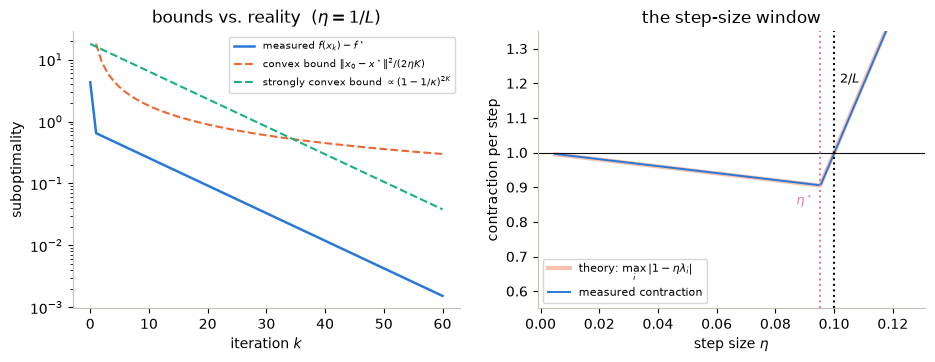

In [3]:
etas = np.linspace(0.005, 0.125, 200)
measured = [np.linalg.norm(gd([1.2, 0.6], e, n=200)[-1]) ** (1 / 200) for e in etas]   # (||x_K||/||x_0||)^(1/K)
predicted = np.maximum(abs(1 - etas * mu), abs(1 - etas * L))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
k = np.arange(61)
xs = gd([1.2, 0.6], 1 / L, n=60)
ax1.semilogy(k, f(xs), color=BLUE, lw=1.8, label=r"measured $f(x_k) - f^\star$")
ax1.semilogy(k[1:], np.linalg.norm(xs[0])**2 / (2 * (1 / L) * k[1:]), "--", color=ORANGE, label=r"convex bound $\|x_0-x^\star\|^2/(2\eta K)$")
ax1.semilogy(k, 0.5 * L * np.linalg.norm(xs[0])**2 * (1 - 1 / 20)**(2 * k), "--", color=AQUA, label=r"strongly convex bound $\propto(1-1/\kappa)^{2K}$")
ax1.set(xlabel="iteration $k$", ylabel="suboptimality", title=r"bounds vs. reality  ($\eta = 1/L$)")
ax1.legend(fontsize=7.5)

ax2.plot(etas, predicted, color=ORANGE, lw=3, alpha=0.4, label=r"theory: $\max_i|1-\eta\lambda_i|$")
ax2.plot(etas, measured, color=BLUE, lw=1.4, label="measured contraction")
ax2.axhline(1, color="#0b0b0b", lw=0.8)
ax2.axvline(2 / L, ls=":", color="#0b0b0b"); ax2.text(2 / L + 0.002, 1.2, r"$2/L$", fontsize=9)
ax2.axvline(2 / (mu + L), ls=":", color=MAGENTA); ax2.text(2 / (mu + L) - 0.002, 0.85, r"$\eta^\star$", color=MAGENTA, ha="right", fontsize=9)
ax2.set(xlabel=r"step size $\eta$", ylabel="contraction per step", ylim=(0.55, 1.35), title="the step-size window")
ax2.legend(fontsize=8, loc="lower left")
plt.show()

Left: the bounds hold, and they are *bounds* — on a strongly convex problem the actual decay is geometric, far below the $O(1/K)$ convex guarantee. Right: the measured contraction follows $\max_i|1-\eta\lambda_i|$ exactly, is minimal at $\eta^\star = 2/(\mu+L)$, and crosses $1$ precisely at $\eta = 2/L$. The theory is sharp here, not conservative.

## 3. Momentum: giving the iterate inertia

Gradient descent is memoryless — it re-decides from scratch at every step, and in a narrow valley it keeps re-making the same mistake. Let the step accumulate a **velocity**:

**Heavy ball** (Polyak, 1964) and **Nesterov acceleration** (1983):

$$v_{k+1} = \beta v_k - \eta \nabla f(x_k), \qquad\qquad v_{k+1} = \beta v_k - \eta \nabla f(x_k + \beta v_k), \qquad\qquad x_{k+1} = x_k + v_{k+1}.$$

They differ only in *where the gradient is measured*: Nesterov first takes the momentum step, then corrects — a look-ahead that damps the overshoot the heavy ball is prone to. With $\beta = 0$ both are gradient descent.

**A dynamical-systems reading.** The heavy-ball step is exactly $x_{k+1} - 2x_k + x_{k-1} = -(1-\beta)(x_k - x_{k-1}) - \eta\nabla f(x_k)$. Put $\beta = 1 - a\sqrt\eta$ and $x_k \approx x(k\sqrt\eta)$: expanding in the time step $\sqrt\eta$ leaves $\ddot x + a \dot x + \nabla f(x) = O(\sqrt\eta)$. The two methods are discretizations of

$$\ddot x(t) + a\,\dot x(t) + \nabla f\big(x(t)\big) = 0 \qquad\text{(heavy ball)}, \qquad\text{against}\qquad \dot x(t) = -\nabla f\big(x(t)\big) \qquad\text{(gradient descent).}$$

Gradient descent is the *overdamped* limit — a particle with no mass, moving only where the force points. The heavy ball is a unit mass in the potential $f$ with friction $a$: it rolls *through* a narrow valley instead of bouncing off its walls. The tuning used below has $a = 2\sqrt{L\mu}/(\sqrt L + \sqrt\mu) \to 2\sqrt\mu$ for $\kappa \gg 1$, and $\ddot x + a\dot x + \mu x = 0$ is critically damped at exactly $a = 2\sqrt\mu$: the optimal momentum critically damps the slowest mode. Less friction and the iterates oscillate, more and we are back to gradient descent. Nesterov's method is the same ODE with vanishing damping $a = 3/t$ (Su, Boyd & Candès, 2016).

**Rates** ($L$-smooth, $\kappa = L/\mu$, one gradient per iteration for all three):

| method | convex | $\mu$-strongly convex |
|---|---|---|
| gradient descent | $O(1/k)$ | $\big(\tfrac{\kappa-1}{\kappa+1}\big)^k \approx (1 - 2/\kappa)^k$ |
| heavy ball | no general guarantee — it can cycle | $\big(\tfrac{\sqrt\kappa-1}{\sqrt\kappa+1}\big)^k$ on quadratics |
| Nesterov | $O(1/k^2)$ | $\big(1 - 1/\sqrt\kappa\big)^k$ |
| **lower bound** for any method using only $\{\nabla f(x_j)\}_{j\le k}$ | $\Omega(1/k^2)$ | $\big(\tfrac{\sqrt\kappa-1}{\sqrt\kappa+1}\big)^k$ |

Momentum turns $\kappa$ into $\sqrt\kappa$ — at $\kappa = 100$, ten times fewer iterations — and Nesterov's method *attains* the Nemirovski–Yudin lower bound (valid while $k \lesssim d$): no first-order method can do better in the worst case. The heavy ball is faster still on quadratics, but without the look-ahead it can cycle forever on a smooth strongly convex function (Lessard, Recht & Packard, 2016) — acceleration and robustness are a trade-off.

Beyond first order: Newton's step $-[\nabla^2 f(x_k)]^{-1}\nabla f(x_k)$ converges at a rate independent of $\kappa$ but costs a linear solve per iteration; Adam and AdaGrad sit in between, preconditioning with a cheap diagonal estimate of the curvature.

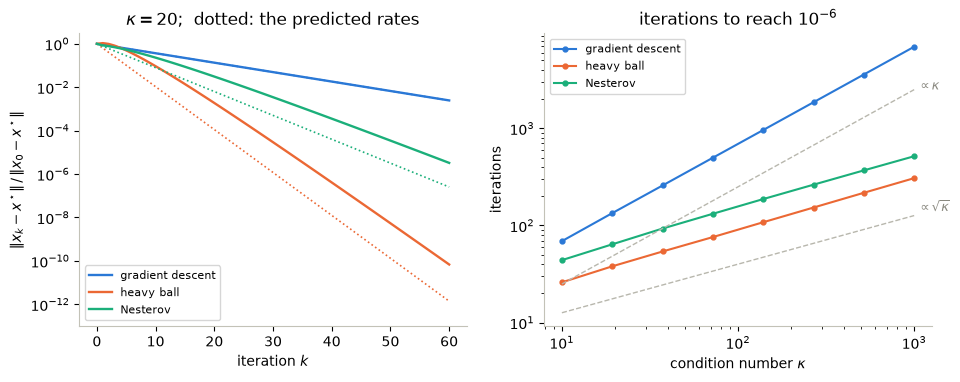

In [4]:
# mu = 1 and L = kappa; the three methods differ only in (eta, beta, look-ahead)
tuning = lambda k: {"gradient descent": (2 / (1 + k), 0.0, False),
                    "heavy ball": (4 / (np.sqrt(k) + 1)**2, ((np.sqrt(k) - 1) / (np.sqrt(k) + 1))**2, False),
                    "Nesterov": (1 / k, (np.sqrt(k) - 1) / (np.sqrt(k) + 1), True)}
rate = lambda k: {"gradient descent": (k - 1) / (k + 1), "heavy ball": (np.sqrt(k) - 1) / (np.sqrt(k) + 1),
                  "Nesterov": 1 - 1 / np.sqrt(k)}

def descent(kappa, method, n=60, x0=(1.2, 0.6)):
    eta, beta, look = tuning(kappa)[method]
    lam, x, v, xs = np.array([1.0, kappa]), np.array(x0, float), np.zeros(2), []
    for _ in range(n + 1):
        xs.append(x.copy())
        v = beta * v - eta * lam * (x + beta * v if look else x)     # lam * y is grad f(y)
        x = x + v
    return np.array(xs)

err = lambda p: np.linalg.norm(p, axis=1) / np.linalg.norm(p[0])
kappas = np.geomspace(10, 1000, 8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for method, col in zip(tuning(20), [BLUE, ORANGE, AQUA]):
    ax1.semilogy(err(descent(20, method)), color=col, lw=1.7, label=method)
    ax1.semilogy(rate(20)[method] ** np.arange(61), ":", color=col, lw=1.2)
    ax2.loglog(kappas, [np.argmax(err(descent(k, method, n=int(8 * k) + 400)) < 1e-6) for k in kappas],
               "-o", color=col, ms=3.5, lw=1.5, label=method)
ax1.set(xlabel="iteration $k$", ylabel=r"$\|x_k - x^\star\| \,/\, \|x_0 - x^\star\|$", ylim=(1e-13, 3),
        title=r"$\kappa = 20$;  dotted: the predicted rates")
ax1.legend(fontsize=8)
for guide, lbl, y in [(2.5 * kappas, r"$\propto \kappa$", 2.5e3), (4 * np.sqrt(kappas), r"$\propto \sqrt{\kappa}$", 1.4e2)]:
    ax2.loglog(kappas, guide, "--", color="#b8b7ad", lw=1)
    ax2.text(1050, y, lbl, color="#8a8980", fontsize=9)
ax2.set(xlabel=r"condition number $\kappa$", ylabel="iterations", title=r"iterations to reach $10^{-6}$")
ax2.legend(fontsize=8, loc="upper left")
plt.show()

Left: each method decays at exactly its predicted rate. Sixty iterations, one gradient each, buy $2.6$ digits of accuracy for gradient descent, $5.5$ for Nesterov and $10.2$ for the heavy ball. Right: the price of ill-conditioning, measured. Gradient descent needs $\Theta(\kappa)$ iterations, both momentum methods $\Theta(\sqrt\kappa)$; at $\kappa = 1000$ that is $6908$ iterations against $516$ and $307$.

The mechanism is visible in the zig-zag of Section 1: across the valley the gradient flips sign at every step, along the valley it keeps it. The velocity $v_{k+1} = -\eta\sum_{j=0}^{k} \beta^{\,k-j}\, \nabla f(x_j)$ is a weighted sum of past gradients, so the alternating component cancels while the consistent one accumulates — momentum damps the oscillation and amplifies the drift.

## 4. Non-convex problems and the stochastic gradient

Machine learning objectives are **empirical risks** over $n$ data points,

$$f(x) = \frac1n \sum_{i=1}^n f_i(x),$$

and they break both assumptions we have been leaning on: $f$ is not convex (Theorem 1 only promises a stationary point, and which one depends on where we start), and $n$ is large enough that one full gradient is expensive.

**Stochastic gradient descent** replaces $\nabla f$ by the gradient of a mini-batch $B_k$ drawn uniformly at random with replacement,

$$x_{k+1} = x_k - \eta_k g_k, \qquad g_k = \frac{1}{|B_k|}\sum_{i \in B_k} \nabla f_i(x_k), \qquad \mathbb{E}[g_k \mid x_k] = \nabla f(x_k), \qquad \mathbb{E}\|g_k - \nabla f(x_k)\|^2 \le \frac{\sigma^2}{|B_k|}.$$

The estimate is unbiased, costs $|B_k| \ll n$ gradients, and carries noise of variance $\sigma^2/|B_k|$.

### Theorem 4 (SGD, non-convex, constant step)

Let $f$ be $L$-smooth and bounded below, $\eta \le 1/L$. Then

$$\frac1K \sum_{k=0}^{K-1} \mathbb{E}\|\nabla f(x_k)\|^2 \;\le\; \underbrace{\frac{2\big(f(x_0) - f^\star\big)}{\eta K}}_{\text{the rate of Theorem 1}} \;+\; \underbrace{\eta L \sigma^2}_{\text{noise floor}}.$$

*Proof.* The descent lemma with $x_{k+1} = x_k - \eta g_k$, in conditional expectation, using $\mathbb{E}[g_k] = \nabla f(x_k)$ and $\mathbb{E}\|g_k\|^2 = \|\nabla f(x_k)\|^2 + \mathbb{E}\|g_k - \nabla f(x_k)\|^2 \le \|\nabla f(x_k)\|^2 + \sigma^2$:

$$\mathbb{E} f(x_{k+1}) \le f(x_k) - \eta\|\nabla f(x_k)\|^2 + \frac{L\eta^2}{2}\big(\|\nabla f(x_k)\|^2 + \sigma^2\big) \le f(x_k) - \frac{\eta}{2}\|\nabla f(x_k)\|^2 + \frac{L\eta^2\sigma^2}{2}.$$

Take total expectations, sum over $k < K$, telescope, and divide by $\eta K/2$. $\blacksquare$

The bound is the deterministic rate plus a floor proportional to $\eta$: with a constant step SGD converges *to a neighbourhood*, not to a point. Choosing $\eta \sim 1/\sqrt{K}$ balances the two terms and gives $O(1/\sqrt K)$; letting $\eta_k$ decay with $\sum_k \eta_k = \infty$ and $\sum_k \eta_k^2 < \infty$ (Robbins–Monro, 1951), for instance $\eta_k = \eta_0/(1 + k/\tau)$, drives the floor to zero.

### The noise is a feature

For small $\eta$ the iteration $x_{k+1} = x_k - \eta\nabla f(x_k) + \eta\big(\nabla f(x_k) - g_k\big)$ is an Euler–Maruyama discretization of the stochastic differential equation

$$dX = -\nabla f(X)\,dt + \sqrt{2T}\,dW, \qquad T = \frac{\eta\sigma^2}{2\,|B|} \quad \text{(isotropic noise of covariance } \tfrac{\sigma^2}{|B|}I),$$

whose stationary density is the Gibbs measure $p_\infty(x) \propto e^{-f(x)/T}$. Gradient descent is the zero-temperature limit $T = 0$: it falls into the nearest basin and stays. SGD runs at temperature $T$, and Kramers' law says the expected time to climb a barrier of height $\Delta E$ scales as $e^{\Delta E / T}$. Three consequences:

- **large steps and small batches are hot**: basins with $\Delta E \lesssim T$ do not hold the iterate, so SGD walks past shallow local minima and saddles;
- **decaying $\eta_k$ is annealing**: the search cools and freezes into a basin — simulated annealing, for free;
- $e^{-f/T}$ weighs basins by volume as well as depth, so SGD prefers **wide** minima — one of the standard explanations for why it generalizes well.

The example below is a one-dimensional empirical risk with $n = 200$ points,

$$f_i(x) = \tfrac14 (x - a_i)^2 + \cos(3x), \qquad a_i \sim \mathcal{N}(1, 6^2), \qquad\text{so}\qquad f(x) = \tfrac14 (x - \bar a)^2 + \cos(3x) + \text{const}.$$

A wrinkled bowl with seven local minima. Note that the spread of the data does not move the minima at all — it only sets the gradient noise, $\sigma = \tfrac12 \operatorname{std}(a) = 3$. Below, the landscape is drawn with $x$ on the *vertical* axis so that the middle panel can follow the iterates through it (on a logarithmic time axis — all the interesting motion happens early). Both runs start at $x_0 = 5$, the bottom of a local basin, and get the same budget of $3000$ iterations; only the batch size and the step-size schedule differ.

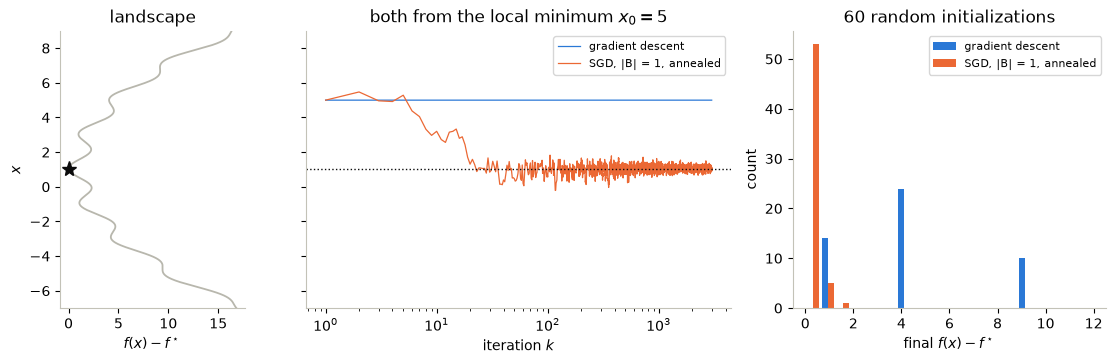

gradient descent         ended in the global basin in 20% of runs
SGD, |B| = 1, annealed   ended in the global basin in 90% of runs


In [5]:
a = np.random.default_rng(0).normal(1.0, 6.0, 200)                     # the data
F  = lambda x: (0.25 * (np.asarray(x)[..., None] - a)**2 + np.cos(3 * np.asarray(x)[..., None])).mean(-1)
dF = lambda x, s: 0.5 * (x - s) - 3 * np.sin(3 * x)                    # gradient of a single sample

def sgd(x0, eta, n=3000, batch=None, seed=0):
    # batch=None is full-batch gradient descent; eta is a schedule k -> step size
    rng, x, xs = np.random.default_rng(seed), float(x0), []
    for k in range(n + 1):
        xs.append(x)
        s = a if batch is None else rng.choice(a, batch)
        x -= eta(k) * np.mean(dF(x, s))
    return np.array(xs)

full, noisy = lambda k: 0.15, lambda k: 0.15 / (1 + k / 600)           # constant vs. annealed step size
x0s = np.random.default_rng(1).uniform(-6, 8, 60)                      # 60 random initializations
runs = {"gradient descent":       (sgd(5.0, full), [sgd(x, full)[-1] for x in x0s]),
        "SGD, |B| = 1, annealed": (sgd(5.0, noisy, batch=1), [sgd(x, noisy, batch=1, seed=i)[-1] for i, x in enumerate(x0s)])}

grid = np.linspace(-7, 9, 1500)
fstar, xstar = F(grid).min(), grid[F(grid).argmin()]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 3.6), gridspec_kw={"width_ratios": [1, 2.3, 1.7]})
ax1.plot(F(grid) - fstar, grid, color="#b8b7ad", lw=1.3)
ax1.plot(0, xstar, "*", color="#0b0b0b", ms=11)
ax1.set(xlabel=r"$f(x) - f^\star$", ylabel="$x$", ylim=(-7, 9), title="landscape")
for (name, (path, _)), col in zip(runs.items(), [BLUE, ORANGE]):
    ax2.plot(np.arange(len(path)) + 1, path, color=col, lw=0.9, label=name)      # log time axis
ax2.axhline(xstar, ls=":", color="#0b0b0b", lw=1)
ax2.tick_params(labelleft=False)
ax2.set(xscale="log", xlabel="iteration $k$", ylim=(-7, 9), title=r"both from the local minimum $x_0 = 5$")
ax2.legend(fontsize=8, loc="upper right")
ax3.hist([F(np.array(e)) - fstar for _, e in runs.values()], bins=np.linspace(0, 12, 20), color=[BLUE, ORANGE], label=list(runs))
ax3.set(xlabel=r"final $f(x) - f^\star$", ylabel="count", title="60 random initializations")
ax3.legend(fontsize=8)
plt.show()

for name, (_, ends) in runs.items():
    print(f"{name:24s} ended in the global basin in {np.mean(np.abs(np.array(ends) - xstar) < 0.5):.0%} of runs")

Gradient descent does exactly what Theorem 1 promises and nothing more. Started at a local minimum it has $\nabla f(x_0) = 0$, so it never moves at all; started anywhere else it slides into the basin that happens to contain $x_0$ and stops at its bottom — with seven basins, the initialization picks the answer. SGD's path is not monotone. While $\eta_k$ is large it climbs out of basin after basin; as the step size decays the temperature $T = \eta_k\sigma^2/2$ drops and the walk freezes, almost always in the deepest one. The noise that made the bound of Theorem 4 *worse* is what makes the optimizer *better*.

This is also why the practical recipe is what it is: large steps and small batches early for exploration, decay for convergence, and a batch size chosen so the temperature $\eta\sigma^2/(2|B|)$ stays useful — not zero.

## Summary

| | update | assumptions | guarantee |
|---|---|---|---|
| gradient descent | $x_{k+1} = x_k - \eta\nabla f(x_k)$ | $L$-smooth, $\eta \le 1/L$ | $\min_k \lVert\nabla f(x_k)\rVert^2 = O(1/K)$ |
| | | $+$ convex | $f(x_K) - f^\star = O(1/K)$ |
| | | $+$ $\mu$-strongly convex | $\lVert x_K - x^\star\rVert = O\big((1-\tfrac{2}{\kappa+1})^K\big)$ |
| heavy ball | $+\ \beta v_k$ | quadratic, tuned $\beta$ | $\kappa \to \sqrt\kappa$, fastest here, no general guarantee |
| Nesterov | $+\ \beta v_k$, look-ahead | same, tuned $\beta$ | $\kappa \to \sqrt\kappa$ and $O(1/K^2)$ convex — optimal |
| SGD | $x_{k+1} = x_k - \eta_k g_k$ | $+$ unbiased, variance $\sigma^2$ | $O(1/\sqrt K)$, noise floor $\eta L \sigma^2$ |

Three ideas carry all of it. $L$-smoothness turns a linear model into a *provable upper bound*, which is why a step of $1/L$ is safe. The condition number $\kappa$, not the dimension, sets the speed, and momentum improves it to $\sqrt\kappa$ — the best any first-order method can do. And in the non-convex world the gradient noise is not merely tolerated: it is the search mechanism.

Next: **05 — control theory**, where the same objects reappear as optimal control problems, and training a neural ODE becomes a matter of steering a dynamical system.